In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate synthetic dataset


In [2]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
y = y.reshape(-1, 1)  # Reshape for consistency

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
X

array([[-0.11166654,  0.52022374],
       [ 1.14264982, -0.34257734],
       [ 0.79555796, -0.01144231],
       ...,
       [ 1.72760808, -0.42882943],
       [-1.01448644,  0.13522904],
       [ 0.77438101,  0.63428493]], shape=(1000, 2))

In [4]:
y

array([[1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
    

In [5]:
X_train

array([[ 2.13965802,  0.37314783],
       [-1.20665488,  0.41689764],
       [-0.21171309,  1.17153886],
       ...,
       [-0.86990505,  0.48557797],
       [ 1.14630776,  0.19416331],
       [ 1.94143074,  0.14949156]], shape=(800, 2))

In [35]:
y_train

array([[1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
    

In [ ]:
# ANN (Artificial Neural Network): This is the broad category. It includes every type of neural network,
# including Feedforward (FPNN), Recurrent (RNN), Convolutional (CNN), and Transformers

In [ ]:
# Build a Sequential model with linear activation

def build_linear_model():
    model = Sequential([
        Dense(4, activation='linear', input_dim=2),  # First layer with linear activation has 2 input features and 2 dimensions
        Dense(1, activation='sigmoid')  # Output layer with 1 neuron for binary classification
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
'''
model = Sequential()
model.add(Dense(4, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

'''

In [7]:
# Build a Sequential model with ReLU activation

def build_relu_model():
    model = Sequential([
        Dense(4, activation='relu', input_dim=2),  # First layer with ReLU activation
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [10]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, epochs, batch_size=32):
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
    y_pred = (model.predict(X_test) > 0.5).astype(int) # greater than 1 will be converted to 1 rest 0
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy,y_pred


In [11]:
linear_model = build_linear_model()
relu_model = build_relu_model()

print("Training linear model...")
linear_accuracy,y_pred = train_and_evaluate(linear_model, X_train, y_train, X_test, y_test,50)
print(f"Accuracy with linear activation: {linear_accuracy:.2f}")



c:\Users\Jagdish singh\jupyter311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training linear model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Accuracy with linear activation: 0.86


In [13]:
# Train and evaluate ReLU model

print("Training ReLU model...")
relu_accuracy,y_pred = train_and_evaluate(relu_model, X_train, y_train, X_test, y_test,50)
print(f"Accuracy with ReLU activation: {relu_accuracy:.2f}")


Training ReLU model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Accuracy with ReLU activation: 0.94



Visualizing decision boundaries...
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


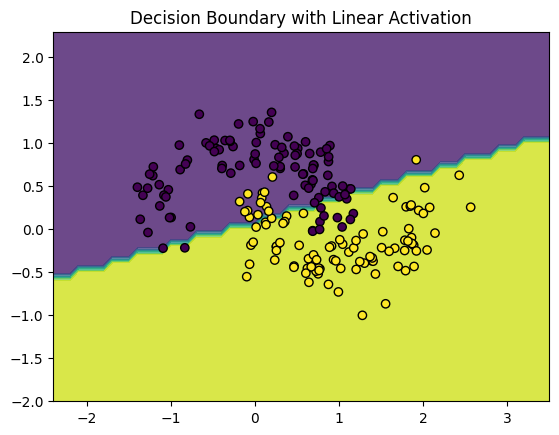

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


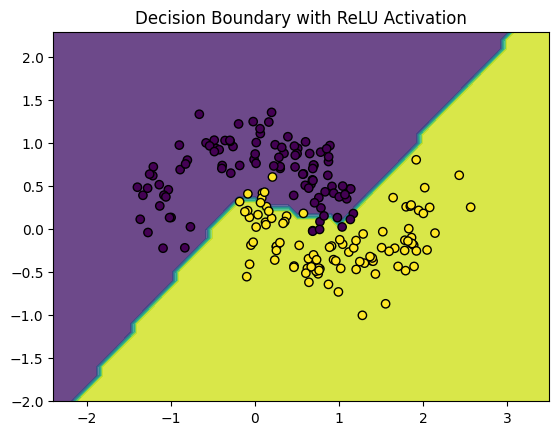

In [14]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = (Z > 0.5).astype(int).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), edgecolor="k")
    plt.title(title)
    plt.show()

# Plot decision boundaries
print("\nVisualizing decision boundaries...")
plot_decision_boundary(linear_model, X_test, y_test, "Decision Boundary with Linear Activation")
plot_decision_boundary(relu_model, X_test, y_test, "Decision Boundary with ReLU Activation")

In [42]:
# decsion boundary of RELU properly seprates non linear complex data while linear sigmod + inear dosnt able to seprate well


Visualizing decision boundaries...
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step


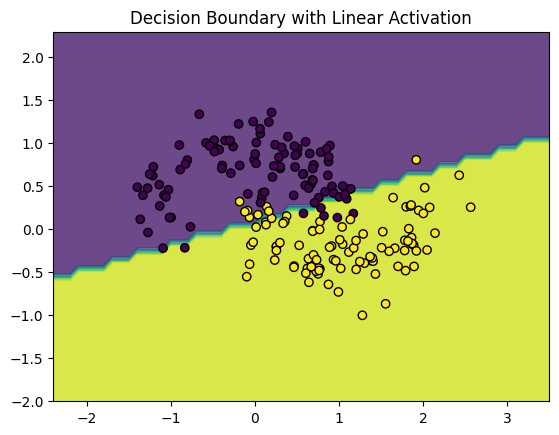

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step


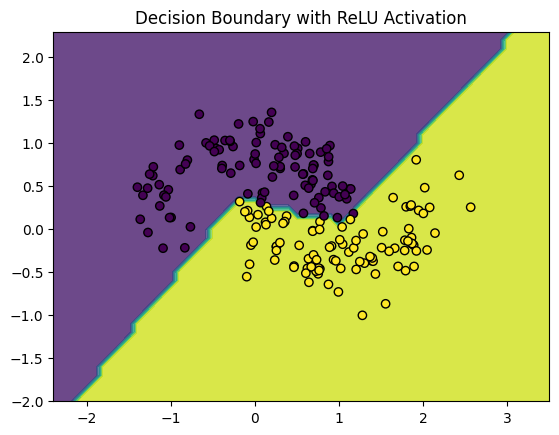

In [15]:
print("\nVisualizing decision boundaries...")
plot_decision_boundary(linear_model, X_test, y_pred, "Decision Boundary with Linear Activation")
plot_decision_boundary(relu_model, X_test, y_pred, "Decision Boundary with ReLU Activation")